In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ethiopia.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [5]:
# Add country column
df["Country"] = "Ethiopia"

# Convert YEAR + DOY into proper date
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

# Extract month
df["Month"] = df["Date"].dt.month

# Check result
df[["YEAR", "DOY", "Date", "Month", "Country"]].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Ethiopia
1,2015,2,2015-01-02,1,Ethiopia
2,2015,3,2015-01-03,1,Ethiopia
3,2015,4,2015-01-04,1,Ethiopia
4,2015,5,2015-01-05,1,Ethiopia


In [6]:
# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

print("Missing values after replacing -999:")
print(df.isna().sum())

print("\n----------------------")

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Drop duplicates if found
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

----------------------
Number of duplicate rows: 0

Dataset shape after removing duplicates:
(4108, 15)


No -999 missing values were found in Ethiopia dataset.
No duplicate rows were detected.
Dataset remained with 4108 rows and 15 columns.

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [8]:
df.describe(include=[np.number])

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,6.423564
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,3.477046
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,12.000000


Average temperature (T2M) = 16.07°C

Maximum temperature (T2M_MAX) reached 30.93°C

Minimum temperature (T2M_MIN) went as low as 1.17°C

Maximum rainfall (PRECTOTCORR) = 82.3 mm

Average humidity (RH2M) = 68.4%

Maximum wind speed (WS2M_MAX) = 7.49 m/s

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage Per Column:")
print(missing_percentage)

print("\nColumns with more than 5% missing values:")
print(missing_percentage[missing_percentage > 5])

Missing Percentage Per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

Columns with more than 5% missing values:
Series([], dtype: float64)


No missing values were found after replacing -999 values.

No columns exceeded 5% missing values.

This indicates the Ethiopia dataset is highly complete and required minimal cleaning.

In [10]:
from scipy.stats import zscore

columns_to_check = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = df[columns_to_check].apply(zscore)

outliers = (abs(z_scores) > 3).any(axis=1)

print("Number of outlier rows:")
print(outliers.sum())

Number of outlier rows:
132


Outlier detection using Z-score identified 132 rows with extreme values. Since climate datasets naturally include extreme weather events such as heavy rainfall, heat waves, or strong winds, these rows were retained instead of being dropped to avoid losing meaningful climate patterns.

In [11]:
# Drop rows where more than 30% values are missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill remaining missing values
df = df.ffill()

print("Remaining missing values:")
print(df.isna().sum())

Remaining missing values:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


### Missing Value Handling

Rows with more than 30% missing values were checked and would have been removed if found. 

The remaining missing values were handled using forward fill (`ffill`) to preserve time-series continuity.

However, after replacing `-999` values and checking nulls, the Ethiopia dataset contained no missing values. Therefore, no rows were dropped and no additional filling was required.

This indicates that the dataset is clean and ready for further analysis.

In [12]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

print("Cleaned Ethiopia dataset exported successfully!")

Cleaned Ethiopia dataset exported successfully!


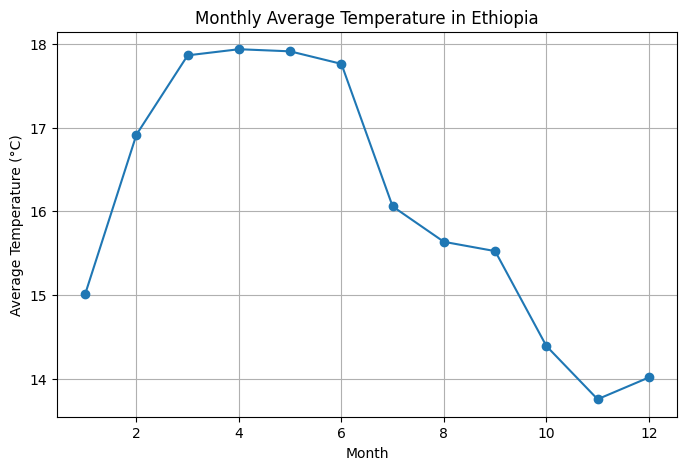

In [13]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature in Ethiopia")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

The monthly average temperature trend shows clear seasonal variation in Ethiopia.

Temperatures increase from January and peak between March and May at approximately 18°C, making these the warmest months.

Temperatures begin declining after June and reach their lowest point in November at approximately 13.8°C.

This suggests a seasonal climate pattern where warmer months occur during spring and early summer, while cooler temperatures occur toward the end of the year.

In [14]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

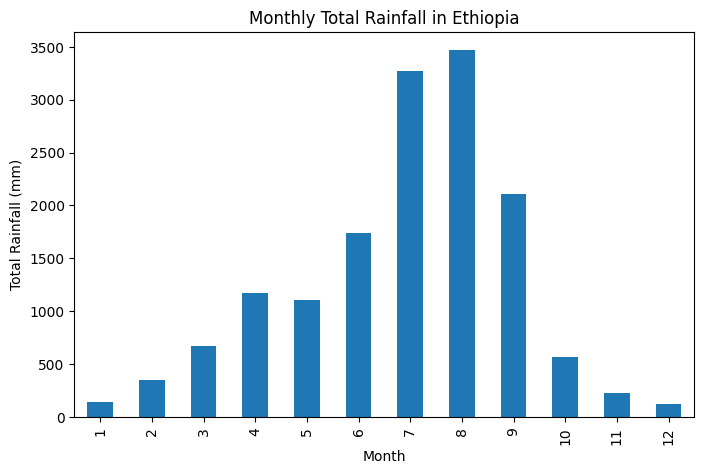

In [15]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall in Ethiopia")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Rainfall Trend Interpretation

The rainfall pattern in Ethiopia shows strong seasonality.

Rainfall gradually increases from January and peaks in July and August, with August recording the highest rainfall.

Rainfall decreases after September and becomes very low in November, December, and January.

This suggests that Ethiopia experiences a concentrated rainy season during mid-year and dry conditions toward the beginning and end of the year.

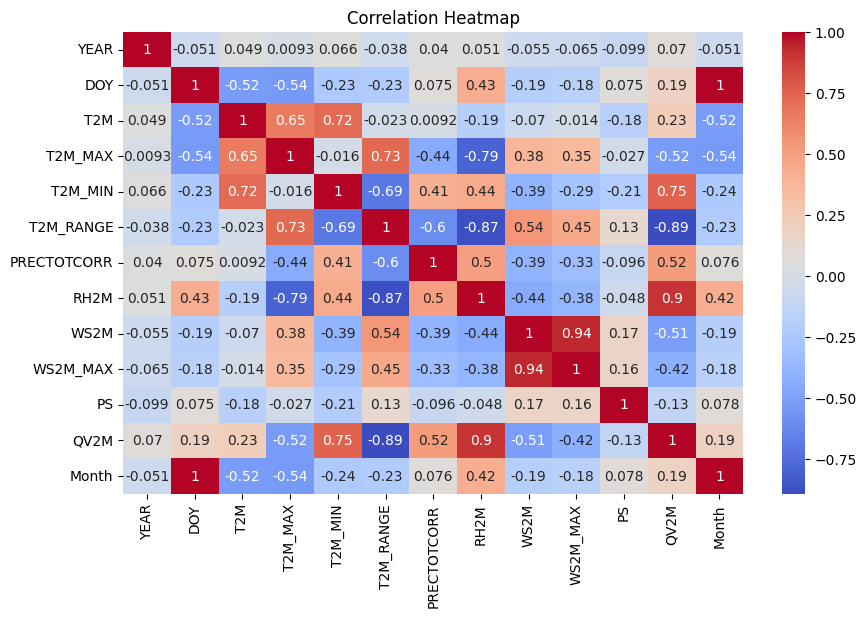

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Interpretation

The correlation heatmap reveals several strong relationships among climate variables.

1. WS2M and WS2M_MAX have a very strong positive correlation (0.94), indicating that higher average wind speeds are associated with higher maximum wind speeds.

2. RH2M and QV2M show a strong positive correlation (0.90), suggesting that higher relative humidity corresponds with higher water vapor content in the atmosphere.

3. T2M_RANGE and QV2M show a strong negative correlation (-0.89), indicating that larger temperature variations are associated with lower atmospheric moisture.

These relationships help explain interactions between temperature, moisture, and wind conditions in Ethiopia.

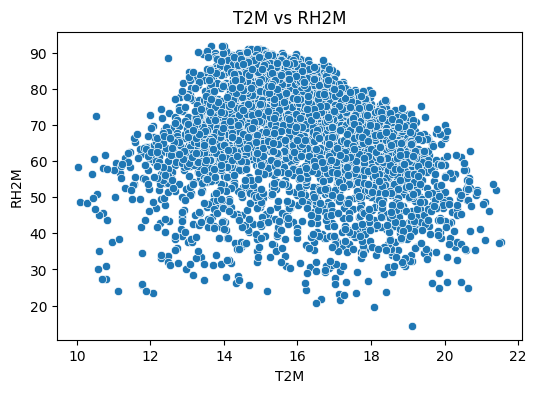

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### Scatter Plot Interpretation: Temperature vs Humidity

The scatter plot shows a weak negative relationship between temperature and humidity.

As temperature increases, humidity tends to decrease slightly, but the relationship is not strong.

Most observations are concentrated between 14°C–18°C temperature and 50%–85% humidity.

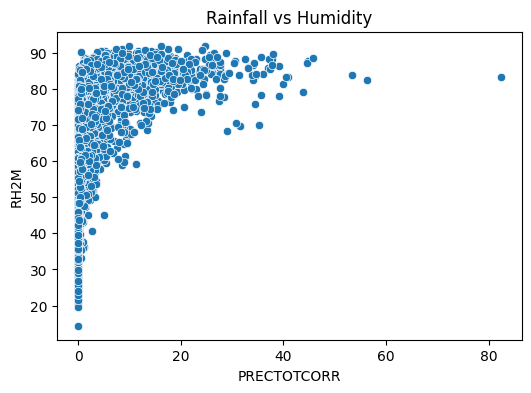

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="PRECTOTCORR", y="RH2M")
plt.title("Rainfall vs Humidity")
plt.show()

### Scatter Plot Interpretation: Rainfall vs Humidity

The scatter plot shows a positive relationship between rainfall and humidity.

Higher rainfall levels generally occur when humidity is high.

Many observations are concentrated around zero rainfall, indicating that dry days are more common than rainy days.

A few extreme rainfall events may represent unusually heavy rain periods.

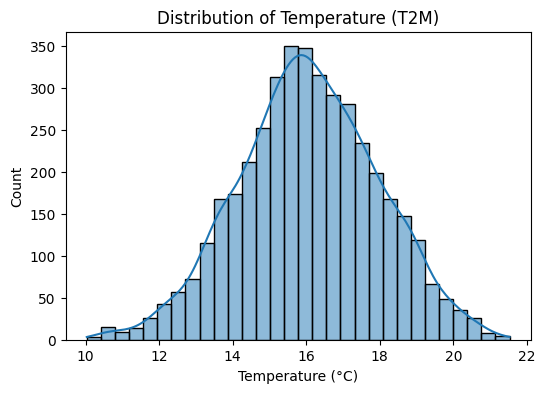

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df["T2M"], bins=30, kde=True)
plt.title("Distribution of Temperature (T2M)")
plt.xlabel("Temperature (°C)")
plt.show()

### Temperature Distribution Interpretation

The temperature distribution appears approximately normal.

Most temperature values are concentrated between 15°C and 17°C, with a peak around 16°C.

Very low and very high temperatures occur less frequently, indicating relatively stable temperature conditions.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

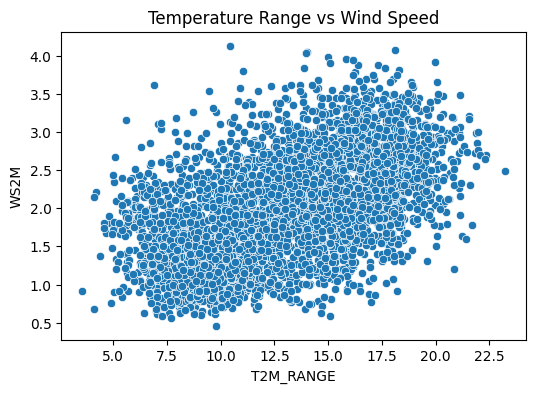

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

### Temperature Range vs Wind Speed Insight

This plot examines whether larger daily temperature variations are associated with stronger wind speeds.

If no clear pattern appears, it suggests a weak relationship between temperature range and wind speed.

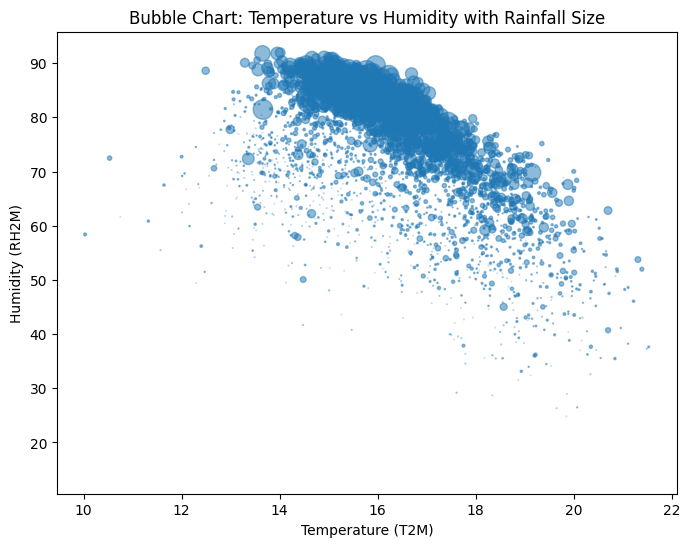

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5,
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity with Rainfall Size")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Insight

This chart shows the relationship between temperature and humidity while using bubble size to represent rainfall.

Larger bubbles indicate higher rainfall events.
Most heavy rainfall events appear under higher humidity conditions.

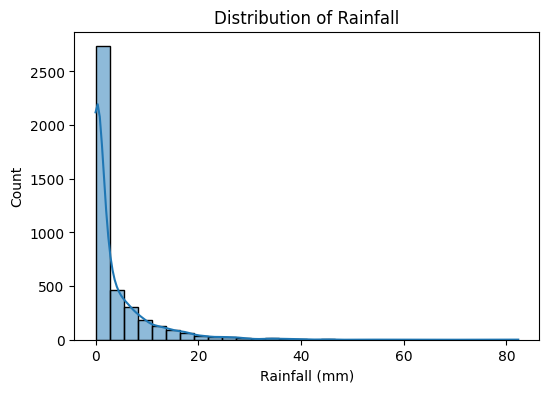

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.show()

### Rainfall Distribution Interpretation

The rainfall distribution is highly right-skewed.

Most observations are concentrated near 0 mm, indicating that dry days are more common.

Heavy rainfall events are rare but can reach very high values, suggesting occasional extreme rainfall occurrences.

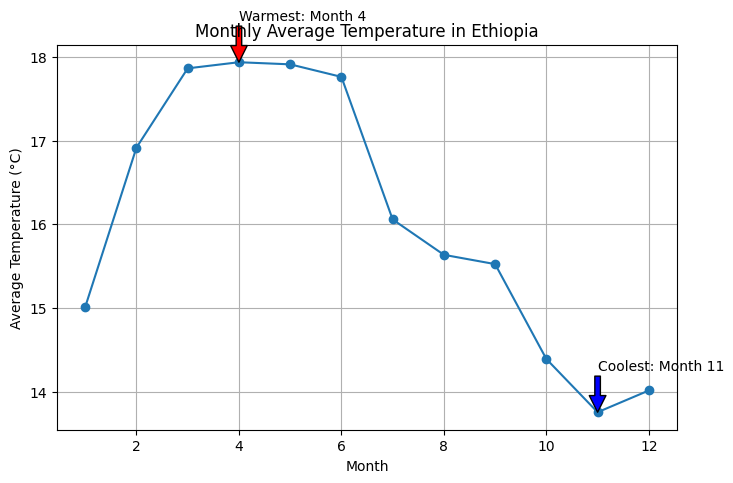

In [24]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")

# Find warmest month
warmest_month = monthly_temp.idxmax()
warmest_temp = monthly_temp.max()

# Find coolest month
coolest_month = monthly_temp.idxmin()
coolest_temp = monthly_temp.min()

# Annotate warmest month
plt.annotate(
    f"Warmest: Month {warmest_month}",
    xy=(warmest_month, warmest_temp),
    xytext=(warmest_month, warmest_temp+0.5),
    arrowprops=dict(facecolor='red')
)

# Annotate coolest month
plt.annotate(
    f"Coolest: Month {coolest_month}",
    xy=(coolest_month, coolest_temp),
    xytext=(coolest_month, coolest_temp+0.5),
    arrowprops=dict(facecolor='blue')
)

plt.title("Monthly Average Temperature in Ethiopia")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

The line chart shows clear seasonal temperature variation in Ethiopia.

- The warmest months are **April and May (Months 4–5)**, where average temperatures reach nearly **18°C**.
- The coolest month is **November (Month 11)**, where average temperature drops to around **13.8°C**.
- Temperatures begin rising from January and peak during spring months before gradually declining toward the end of the year.

This indicates a noticeable seasonal climate pattern across Ethiopia.

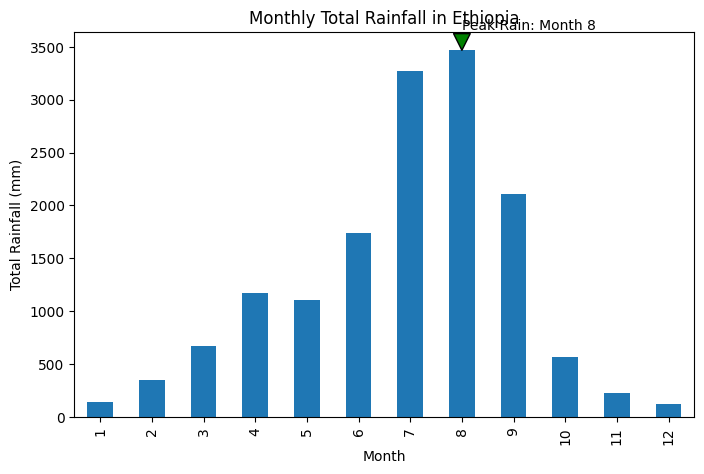

In [25]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")

# Peak rainfall month
peak_month = monthly_rain.idxmax()
peak_rain = monthly_rain.max()

plt.annotate(
    f"Peak Rain: Month {peak_month}",
    xy=(peak_month-1, peak_rain),
    xytext=(peak_month-1, peak_rain+200),
    arrowprops=dict(facecolor='green')
)

plt.title("Monthly Total Rainfall in Ethiopia")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Monthly Rainfall Trend Interpretation

The rainfall chart shows strong seasonal rainfall patterns in Ethiopia.

- The peak rainy months are **July and August (Months 7–8)**.
- August records the highest total rainfall.
- Rainfall is very low during **January, February, November, and December**.

This suggests that Ethiopia experiences its main rainy season during mid-year, while the beginning and end of the year are relatively dry periods.

# Final EDA Summary

## Data Cleaning

- Loaded Ethiopia climate dataset successfully.

- Converted YEAR and DOY into a proper Date column.

- Created Month column for monthly analysis.
- Replaced invalid `-999` values with NaN.
- No missing values remained after cleaning.
- No duplicate rows were found.
- Cleaned dataset was exported successfully.

## Descriptive Statistics
- Dataset contains 4,108 records.
- Average temperature: ~16°C
- Average humidity: ~68%
- Average rainfall: ~3.63 mm
- Temperature ranges from ~10°C to ~21°C.

## Outlier Analysis
- Detected 132 outlier rows using Z-score method.
- These likely represent extreme weather conditions.

## Monthly Trends
- Temperature peaks around March–June.
- Temperature drops during October–November.
- Rainfall peaks around July–August.
- Dry months are mainly January, November, and December.

## Correlation Insights
- Rainfall and humidity show a positive relationship.
- Temperature and humidity show a weak negative relationship.

## Distribution Insights
- Temperature follows an approximately normal distribution.
- Rainfall is highly right-skewed, with many dry days and few heavy rainfall events.

## Conclusion
The Ethiopia climate dataset is clean and suitable for analysis.  
The country experiences moderate temperatures throughout the year, seasonal rainfall peaks, and occasional extreme weather events.